In [11]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [12]:
%cd /g/data/w42/dr6273/work/wind_drought/
import functions as fn

%load_ext autoreload
%autoreload 2

/g/data/w42/dr6273/work/wind_drought
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
FILEPATH = "/g/data/ng72/dr6273/work/projects/wind_drought/data/"

### Load data

In [17]:
ws_dict = fn.load_reanalysis_wind_speed(FILEPATH)

In [19]:
# Check size
nbytes = []
for k, v in ws_dict.items():
    nbytes.append(v.nbytes)
sum(nbytes) / 1024 ** 3

0.00450664758682251

### Drought definition

10th percentile, based on AEMO report for wind lulls (pg 31, Fig 41): https://www.aemo.com.au/-/media/files/major-publications/qed/2025/qed-q3-2025.pdf?rev=7436be91333e4603bc59158b0bf095a1&sc_lang=en&hash=A49B4BC337B25B842566B8F5EE4C8331 

In [20]:
def cumsum_reset_on_mask(data, mask, dim="time"):
    """
    Cumulative sum of `data` along `dim`, resetting to zero wherever `mask` == 0.
    
    Parameters
    ----------
    data : xr.DataArray
        Array to accumulate.
    mask : xr.DataArray
        Binary array of the same shape, where 0 means "reset".
    dim : str
        Dimension along which to accumulate (default: "time").
        
    Returns
    -------
    xr.DataArray
        Same shape as `data`, cumulative sum with resets.
    """
    a = data.values
    reset = (mask.values == 0)

    out = np.zeros_like(a, dtype=float)

    axis = data.get_axis_num(dim)
    a = np.moveaxis(a, axis, 0)
    reset = np.moveaxis(reset, axis, 0)
    out = np.moveaxis(out, axis, 0)

    acc = np.zeros_like(a[0], dtype=float)
    for i in range(a.shape[0]):
        acc = np.where(reset[i], 0, acc + a[i])
        out[i] = acc

    out = np.moveaxis(out, 0, axis)
    return xr.DataArray(out, coords=data.coords, dims=data.dims, attrs=data.attrs)


In [21]:
DROUGHT_Q = 0.1

In [22]:
for k,v in ws_dict.items():
    ws_dict[k] = v.to_dataset(name=v.name)
    ds = ws_dict[k]

    # Compute drought days and cumulative lengths
    drought_days = xr.where(v < v.quantile(DROUGHT_Q, "time"), 1, 0)
    drought_sum = cumsum_reset_on_mask(drought_days, drought_days).astype("int")

    # Accumulate wind speed anomalies over drought days
    ws_clim = v.mean("time")
    ws_anoms = v - ws_clim
    ws_severity = cumsum_reset_on_mask(ws_anoms, drought_days)
    
    # ds["drought_len_p"+str(int(DROUGHT_Q*100))] = drought_sum
    # ds["drought_severity_p"+str(int(DROUGHT_Q*100))] = ws_severity

    ws_dict[k]["drought_len_p"+str(int(DROUGHT_Q*100))] = drought_sum
    ws_dict[k]["drought_severity_p"+str(int(DROUGHT_Q*100))] = ws_severity

In [ ]:
def sel_and_reindex(da, time):
    """
    Return selected array without timestamps

    da: array
    time: time selector for xarray array e.g. slice, string
    """
    da = da.sel(time=time)
    da["time"] = range(len(da["time"]))
    return da

In [64]:
def plot_ts_year_comparison(ax, da, time, roll, q, color="tab:blue", label="", title=""):
    """
    Time series plot of data

    ax: axes to plot on
    da: array
    time: time selector for xarray array e.g. slice, string
    roll: int, number of time steps in rolling average
    q: quantile, drought definition
    color: str, color of line
    label: str, line label
    title: str, plot title
    """
    # rolling mean
    da_roll = da.rolling(time=roll).mean()

    # drought threshold
    da_q = da_roll.quantile(q, "time")
    
    # Select dates to plot
    da_plot = sel_and_reindex(da_roll, time)

    # plot
    da_plot.plot(ax=ax, color=color, label=label)
    ax.axhline(da_q, color=color)
    ax.set_title(title)

In [132]:
years = ["2010", "2017", "2024"]

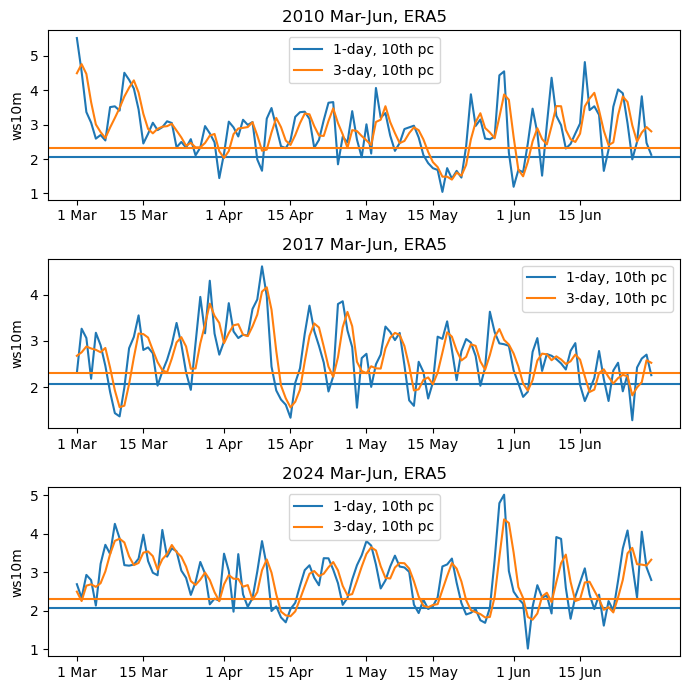

In [133]:
fig, ax = plt.subplots(3, 1, figsize=(7, 7))

# for i, year in enumerate([years[j] for j in [0, -2, -1]]):
for i, year in enumerate(years):
    time = slice("03-"+year, "06-"+year)
    d = pd.date_range("03-"+year, "30-06-"+year)

    plot_ts_year_comparison(
        ax[i],
        ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
        time,
        1,
        DROUGHT_Q,
        label="1-day, 10th pc"
    )
    plot_ts_year_comparison(
        ax[i],
        ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
        time,
        3,
        DROUGHT_Q,
        color="tab:orange",
        label="3-day, 10th pc",
        title=year + " Mar-Jun, ERA5"
    )
    ax[i].legend()

    ax[i].set_xlabel("")
    ax[i].set_xticks(np.where((d.day == 1) | (d.day == 15))[0])
    ax[i].set_xticklabels([
        "1 Mar", "15 Mar","1 Apr", "15 Apr", "1 May", "15 May", "1 Jun", "15 Jun"
    ])
plt.tight_layout()

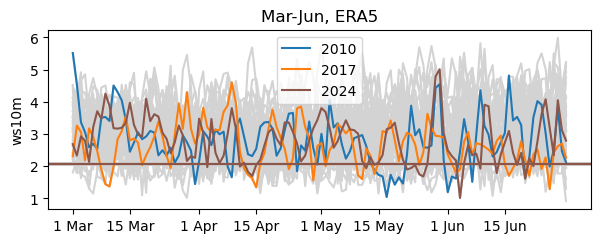

In [138]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7/3))

all_years = [str(i) for i in range(1979, 2025)]

for i, year in enumerate(all_years):
    time = slice("03-"+year, "06-"+year)
    d = pd.date_range("03-"+year, "30-06-"+year)

    plot_ts_year_comparison(
        ax,
        ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
        time,
        1,
        DROUGHT_Q,
        color="lightgray",
    )

for i, (year, color) in enumerate(zip(
    years, ["tab:blue", "tab:orange", "tab:brown"]#, "tab:green", "tab:pink"]
)):
    time = slice("03-"+year, "06-"+year)

    plot_ts_year_comparison(
        ax,
        ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
        time,
        1,
        DROUGHT_Q,
        color=color,
        label=year,
        title="Mar-Jun, ERA5"
    )
    ax.legend()

    ax.set_xlabel("")
    ax.set_xticks(np.where((d.day == 1) | (d.day == 15))[0])
    ax.set_xticklabels([
        "1 Mar", "15 Mar","1 Apr", "15 Apr", "1 May", "15 May", "1 Jun", "15 Jun"
    ])
# plt.tight_layout()

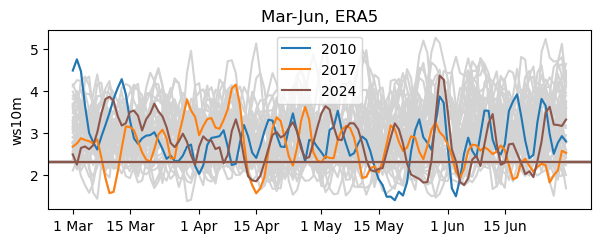

In [136]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7/3))

all_years = [str(i) for i in range(1979, 2025)]

for i, year in enumerate(all_years):
    time = slice("03-"+year, "06-"+year)
    d = pd.date_range("03-"+year, "30-06-"+year)

    plot_ts_year_comparison(
        ax,
        ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
        time,
        3,
        DROUGHT_Q,
        color="lightgray",
    )

for i, (year, color) in enumerate(zip(years, ["tab:blue", "tab:orange", "tab:brown"])):
    time = slice("03-"+year, "06-"+year)

    plot_ts_year_comparison(
        ax,
        ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
        time,
        3,
        DROUGHT_Q,
        color=color,
        label=year,
        title="Mar-Jun, ERA5"
    )
    ax.legend()

    ax.set_xlabel("")
    ax.set_xticks(np.where((d.day == 1) | (d.day == 15))[0])
    ax.set_xticklabels([
        "1 Mar", "15 Mar","1 Apr", "15 Apr", "1 May", "15 May", "1 Jun", "15 Jun"
    ])
# plt.tight_layout()

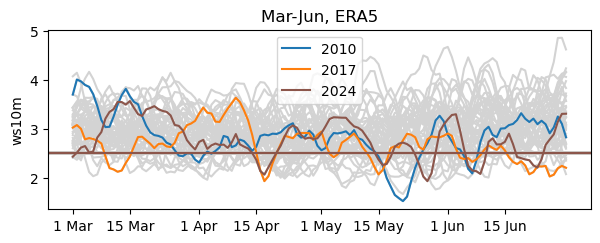

In [137]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7/3))

all_years = [str(i) for i in range(1979, 2025)]

for i, year in enumerate(all_years):
    time = slice("03-"+year, "06-"+year)
    d = pd.date_range("03-"+year, "30-06-"+year)

    plot_ts_year_comparison(
        ax,
        ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
        time,
        7,
        DROUGHT_Q,
        color="lightgray",
    )

for i, (year, color) in enumerate(zip(years, ["tab:blue", "tab:orange", "tab:brown"])):
    time = slice("03-"+year, "06-"+year)

    plot_ts_year_comparison(
        ax,
        ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
        time,
        7,
        DROUGHT_Q,
        color=color,
        label=year,
        title="Mar-Jun, ERA5"
    )
    ax.legend()

    ax.set_xlabel("")
    ax.set_xticks(np.where((d.day == 1) | (d.day == 15))[0])
    ax.set_xticklabels([
        "1 Mar", "15 Mar","1 Apr", "15 Apr", "1 May", "15 May", "1 Jun", "15 Jun"
    ])
# plt.tight_layout()

In [51]:
fig, ax = plt.subplots(2, 1)

ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"].sel(
    time=slice("04-2024", "30-06-2024")
).plot(ax=ax[0])
ax[0].axhline(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"].quantile(0.1, "time")
)
ax[0].set_title("Q2 2024, 1-day, 10th percentile, ERA5")

ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["wss"].sel(
    time=slice("04-2024", "30-06-2024")
).plot(ax=ax[1])
ax[1].axhline(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["wss"].quantile(0.1, "time")
)
ax[1].set_title("Q2 2024, 1-day, 10th percentile, BARRA-R2")

plt.tight_layout()

<xarray.DataArray 'ws10m' (time: 91)> Size: 728B
array([3.47895 , 3.031439, 1.97294 , 3.467232, 2.422928, 2.098143, 2.327418,
       3.013339, 3.805646, 3.166405, 1.990154, 2.110316, 1.82439 , 1.69666 ,
       2.041925, 2.203422, 2.644704, 3.051466, 3.177144, 2.855793, 2.657968,
       3.361528, 3.35799 , 3.06399 , 2.712837, 2.150232, 2.329442, 2.808385,
       3.178187, 3.436171, 3.805183, 3.688748, 3.195283, 2.575722, 2.784335,
       3.143015, 3.427455, 3.143785, 3.121283, 3.007806, 2.155814, 1.937031,
       2.28278 , 2.04285 , 2.115259, 2.347461, 3.147146, 3.198733, 3.352006,
       2.724273, 2.197708, 1.899901, 1.943557, 2.037164, 1.75055 , 1.683322,
       2.072818, 3.307866, 4.790146, 5.009853, 3.027372, 2.493616, 2.313484,
       2.177681, 1.014987, 2.101225, 2.660798, 2.342526, 2.39037 , 1.927407,
       3.910263, 3.862803, 2.591761, 1.788239, 2.365375, 2.733376, 3.09782 ,
       2.419426, 2.039582, 2.415257, 1.61041 , 2.248154, 2.003047, 2.773932,
       3.612324, 4.081565, 3.192746, 2.340125, 4.05011 , 3.122741, 2.794959])
Coordinates:
  * time      (time) int64 728B 0 1 2 3 4 5 6 7 8 ... 82 83 84 85 86 87 88 89 90
    quantile  float64 8B 0.1

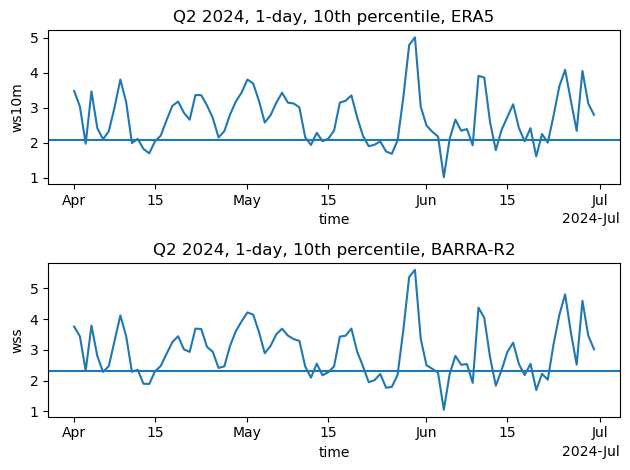

In [44]:
fig, ax = plt.subplots(2, 1)

ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"].sel(
    time=slice("04-2024", "30-06-2024")
).plot(ax=ax[0])
ax[0].axhline(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"].quantile(0.1, "time")
)
ax[0].set_title("Q2 2024, 1-day, 10th percentile, ERA5")

ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["wss"].sel(
    time=slice("04-2024", "30-06-2024")
).plot(ax=ax[1])
ax[1].axhline(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["wss"].quantile(0.1, "time")
)
ax[1].set_title("Q2 2024, 1-day, 10th percentile, BARRA-R2")

plt.tight_layout()

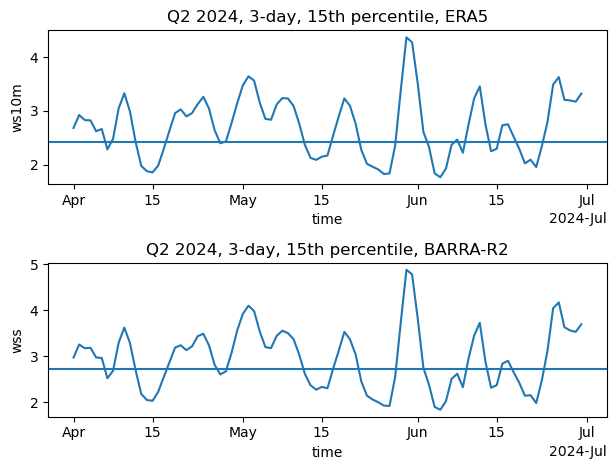

In [45]:
fig, ax = plt.subplots(2, 1)

ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"].rolling(
    time=3
).mean().sel(
    time=slice("04-2024", "30-06-2024")
).plot(ax=ax[0])
ax[0].axhline(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"].rolling(
    time=3
).mean().quantile(
        0.15, "time"
    )
)
ax[0].set_title("Q2 2024, 3-day, 15th percentile, ERA5")

ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["wss"].rolling(
    time=3
).mean().sel(
    time=slice("04-2024", "30-06-2024")
).plot(ax=ax[1])
ax[1].axhline(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["wss"].rolling(
    time=3
).mean().quantile(
        0.15, "time"
    )
)
ax[1].set_title("Q2 2024, 3-day, 15th percentile, BARRA-R2")

plt.tight_layout()

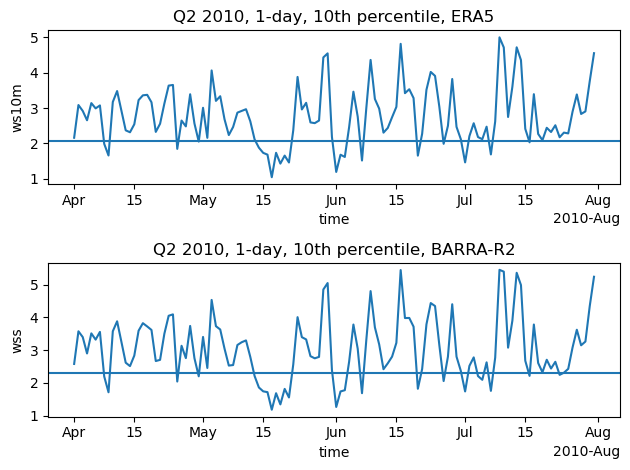

In [46]:
fig, ax = plt.subplots(2, 1)

ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"].sel(
    time=slice("04-2010", "31-07-2010")
).plot(ax=ax[0])
ax[0].axhline(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"].quantile(0.1, "time")
)
ax[0].set_title("Q2 2010, 1-day, 10th percentile, ERA5")

ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["wss"].sel(
    time=slice("04-2010", "31-07-2010")
).plot(ax=ax[1])
ax[1].axhline(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["wss"].quantile(0.1, "time")
)
ax[1].set_title("Q2 2010, 1-day, 10th percentile, BARRA-R2")

plt.tight_layout()

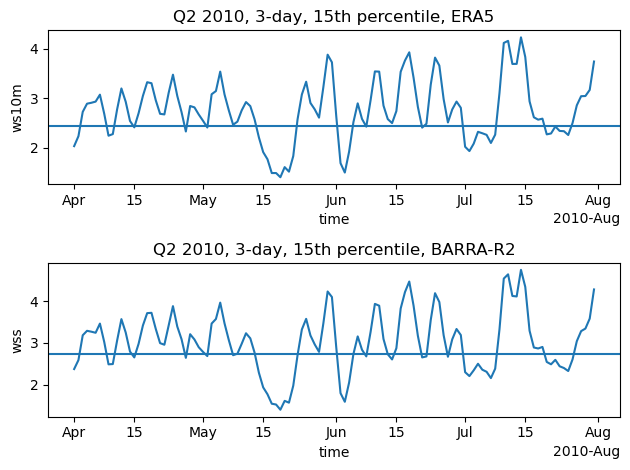

In [47]:
fig, ax = plt.subplots(2, 1)

ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"].rolling(
    time=3
).mean().sel(
    time=slice("04-2010", "31-07-2010")
).plot(ax=ax[0])
ax[0].axhline(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"].rolling(
    time=3
).mean().quantile(
        0.15, "time"
    )
)
ax[0].set_title("Q2 2010, 3-day, 15th percentile, ERA5")

ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["wss"].rolling(
    time=3
).mean().sel(
    time=slice("04-2010", "31-07-2010")
).plot(ax=ax[1])
ax[1].axhline(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["wss"].rolling(
    time=3
).mean().quantile(
        0.15, "time"
    )
)
ax[1].set_title("Q2 2010, 3-day, 15th percentile, BARRA-R2")

plt.tight_layout()

### Drought metrics

Number of drought days per year

In [10]:
def n_drought_days(da):
    """
    Return number of drought days per year
    """
    # return da.resample(time="1YS").sum()
    return xr.where(da > 0, 1, 0).resample(time="1YS").sum()

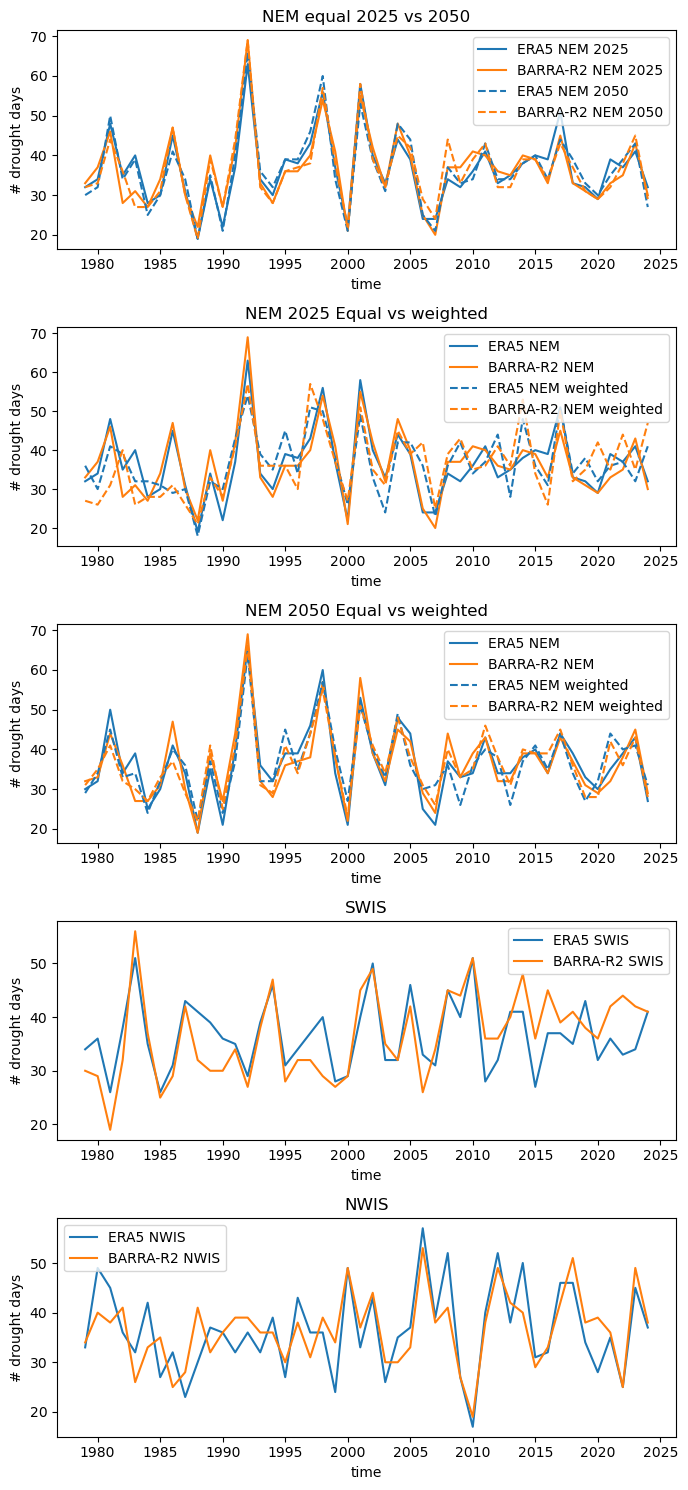

In [30]:
fig, ax = plt.subplots(5, 1, figsize=(7, 15))

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="ERA5 NEM 2025")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[1], label="ERA5 NEM")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[1], label="BARRA-R2 NEM")

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[2], label="ERA5 NEM")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[2], label="BARRA-R2 NEM")

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

n_drought_days(
    ws_dict["ERA5_SWIS"]["drought_len_p10"]
).plot(ax=ax[3], label="ERA5 SWIS")
n_drought_days(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"]
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

n_drought_days(
    ws_dict["ERA5_NWIS"]["drought_len_p10"]
).plot(ax=ax[4], label="ERA5 NWIS")
n_drought_days(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"]
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("# drought days")

plt.tight_layout()

Number of drought periods per year

In [11]:
def n_droughts(da, min_len=1):
    """
    Return number of droughts of a minimum length per year
    """
    # Set drought days that occur in drought periods as 1, else 0
    binary = xr.where(da >= min_len, 1, 0)
    # Find days that are end of droughts (this enables cross-year droughts counted in end year)
    diff = binary.diff("time").shift(time=-1)
    # Count these days per year
    return xr.where(diff == -1, 1, 0).resample(time="1YS").sum()

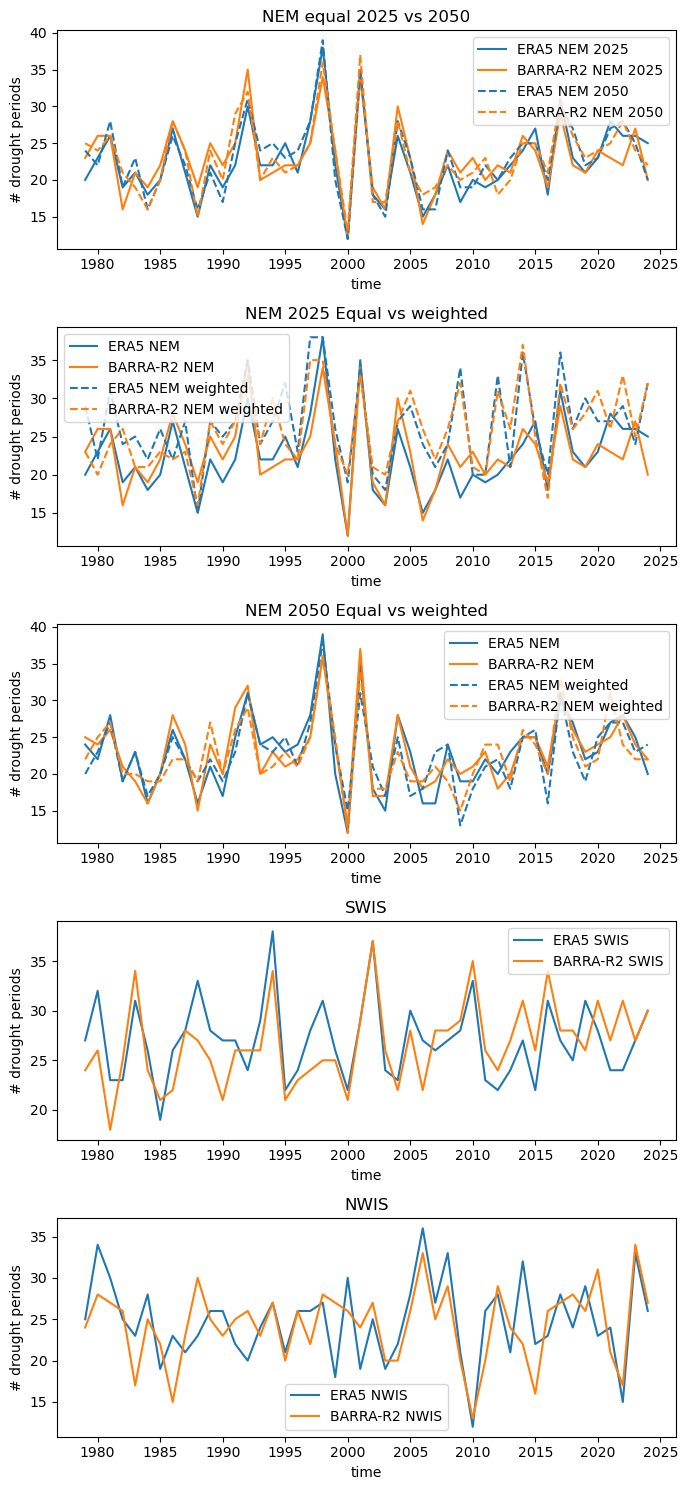

In [36]:
min_len = 1

fig, ax = plt.subplots(5, 1, figsize=(7, 15))

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2025")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="ERA5 SWIS")
n_droughts(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

n_droughts(
    ws_dict["ERA5_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="ERA5 NWIS")
n_droughts(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("# drought periods")
    
plt.tight_layout()

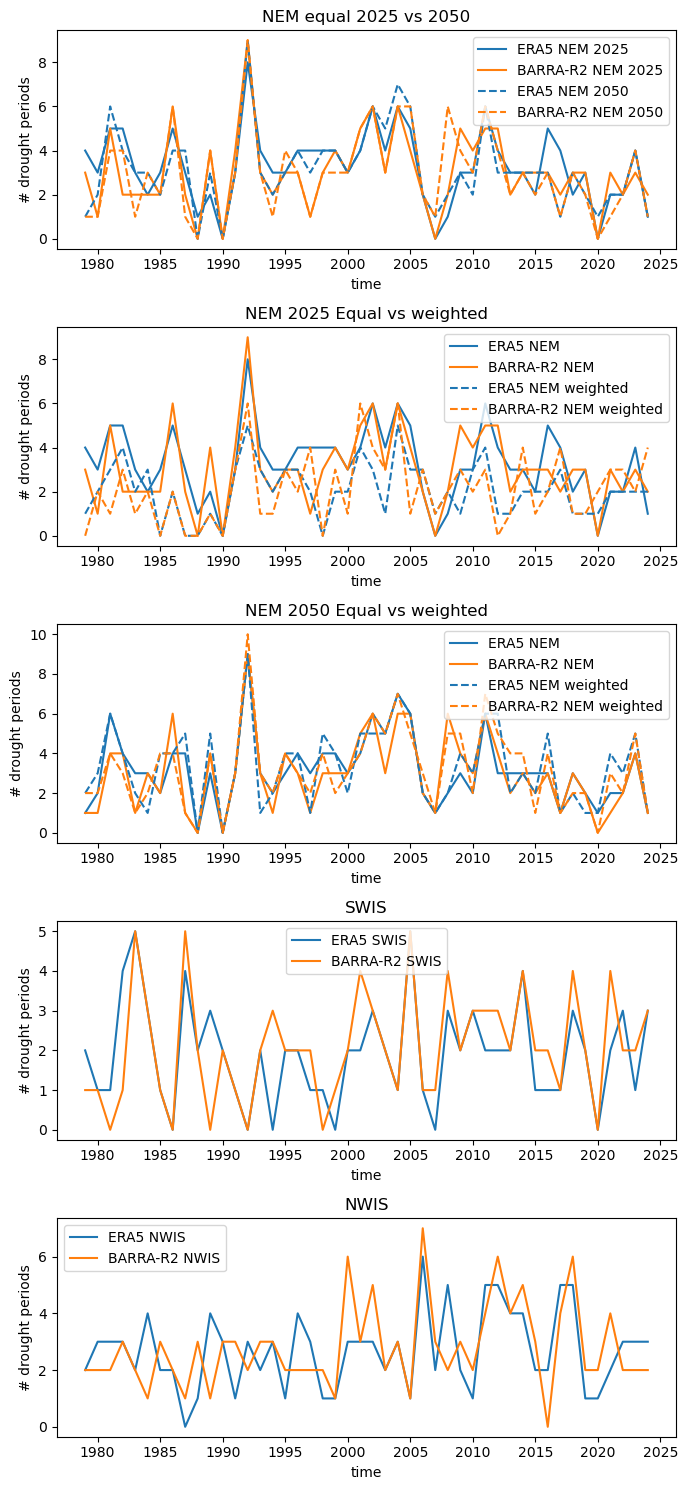

In [37]:
min_len = 3

fig, ax = plt.subplots(5, 1, figsize=(7, 15))

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2025")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="ERA5 SWIS")
n_droughts(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

n_droughts(
    ws_dict["ERA5_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="ERA5 NWIS")
n_droughts(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("# drought periods")
    
plt.tight_layout()

Longest drought per year

In [12]:
def longest_drought(da):
    """
    Return longest drought each year
    """
    return da.groupby("time.year").max()

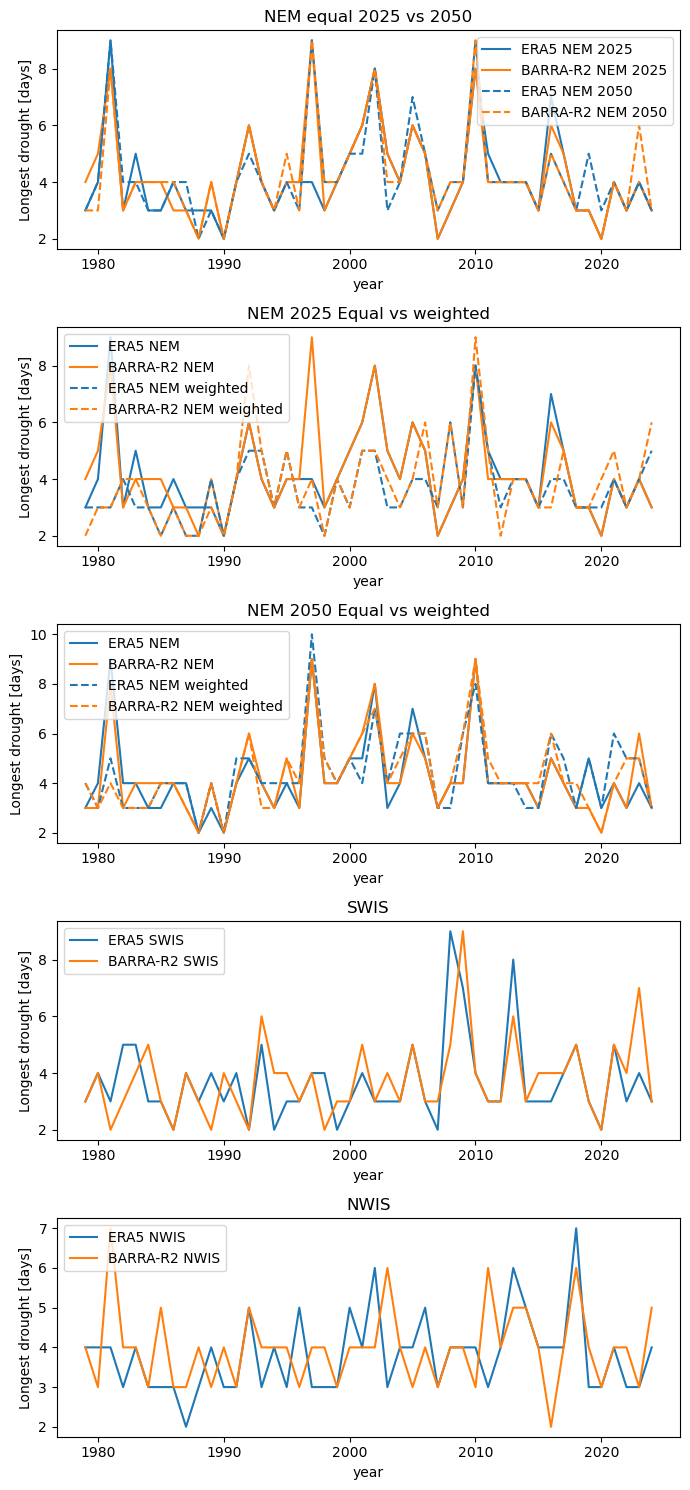

In [34]:
fig, ax = plt.subplots(5, 1, figsize=(7, 15))

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="ERA5 NEM 2025")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[1], label="ERA5 NEM")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[1], label="BARRA-R2 NEM")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[2], label="ERA5 NEM")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[2], label="BARRA-R2 NEM")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

longest_drought(
    ws_dict["ERA5_SWIS"]["drought_len_p10"]
).plot(ax=ax[3], label="ERA5 SWIS")
longest_drought(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"]
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

longest_drought(
    ws_dict["ERA5_NWIS"]["drought_len_p10"]
).plot(ax=ax[4], label="ERA5 NWIS")
longest_drought(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"]
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("Longest drought [days]")
    
plt.tight_layout()

Accumulated drought intensity

In [13]:
def max_intensity(da, mask, min_len=1):
    """
    Return annual max of drought intensity

    da: array of accumulated wind speed anomalies on drought days
    mask: array of drought periods
    min_len: int, minimum number of consecutive drought days per drought period
    """
    # Set drought days that occur in drought periods as 1, else 0
    binary = xr.where(mask >= min_len, 1, 0)
    # Find days that are end of droughts (this enables cross-year droughts counted in end year)
    diff = binary.diff("time").shift(time=-1)
    # Count these days per year
    return da.where(diff == -1).resample(time="1YS").min()

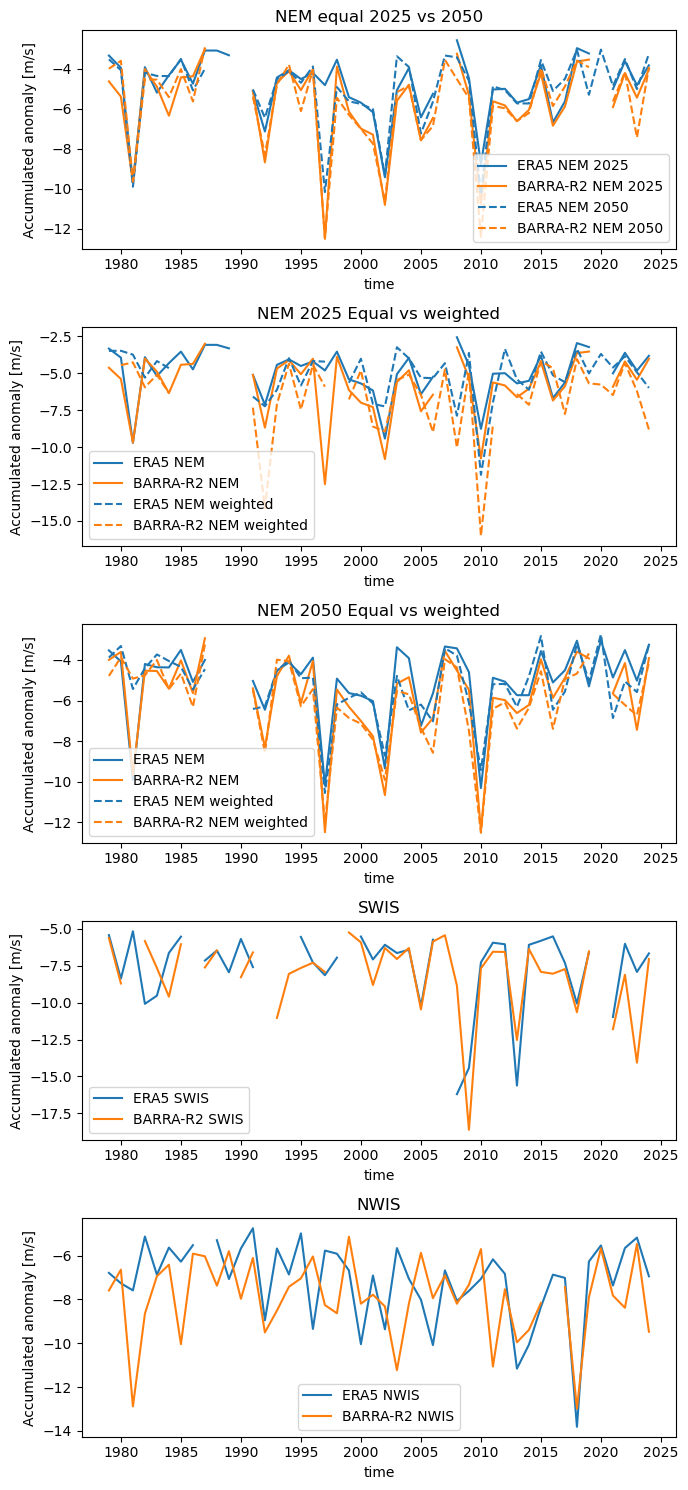

In [43]:
min_len = 3

fig, ax = plt.subplots(5, 1, figsize=(7, 15))

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2025")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

max_intensity(
    ws_dict["ERA5_SWIS"]["drought_severity_p10"],
    ws_dict["ERA5_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="ERA5 SWIS")
max_intensity(
    ws_dict["BARRA-R2_SWIS"]["drought_severity_p10"],
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

max_intensity(
    ws_dict["ERA5_NWIS"]["drought_severity_p10"],
    ws_dict["ERA5_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="ERA5 NWIS")
max_intensity(
    ws_dict["BARRA-R2_NWIS"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("Accumulated anomaly [m/s]")
    
plt.tight_layout()